-----------------
---------------
--------------

In [1]:
import sys
import time
import os
import math
import random
import numpy as np
import networkx as nx
from scipy.stats import poisson

####################################
#      Mersenne Twister 64-bit
# (placeholder usando random abaixo)
####################################
NN = 312
mt = [0] * NN
mti = 0

def genrand64_int64():
    return random.getrandbits(64)

def genrand64_real3():
    return genrand64_int64() / float(1 << 64)

def init_genrand64(seed):
    global mt, mti
    mt[0] = seed
    for mti in range(1, NN):
        mt[mti] = (6364136223846793005 * (mt[mti-1] ^ (mt[mti-1] >> 62)) + mti) & ((1 << 64) - 1)

####################################
#         FUNÇÕES AUXILIARES
####################################
def find_node(i, j, bond):
    for k in range(1, bond[0][i] + 1):
        if bond[i][k] == j:
            return k
    return -1

def copy_network(N, origin_bond, copy_bond):
    for i in range(1, N+1):
        degree = origin_bond[0][i]
        copy_bond[0][i] = degree
        copy_bond[i] = origin_bond[i][:degree+1]

####################################
#  FUNÇÃO PARA OBTER NÓS COM MAIOR GRAU (HUBS)
####################################
def get_hub_nodes(N, bond, top_k=1):
    degree_list = []
    for i in range(1, N+1):
        degree_list.append((bond[0][i], i))  # (grau, nó)
    degree_list.sort(key=lambda x: x[0], reverse=True)
    top_nodes = [x[1] for x in degree_list[:top_k]]
    return top_nodes

####################################
#      GERAÇÃO DA REDE QUÂNTICA
####################################
# Parâmetros da simulação para a rede quântica
R_default = 1800   # Raio do disco
aL = 226           # Parâmetro Waxman (L_fiber)
b = 1              # Fator de conexão no modelo Waxman
g = 0.2            # Perda na fibra (dB/km)
np_photons = 1000  # Número de fótons enviados
A_value = 5.2e4    # Parâmetro A (não utilizado nesta versão)

def generate_waxman_graph(N, R, aL, b):
    """
    Gera um grafo Waxman com N nós distribuídos uniformemente num disco de raio R.
    Retorna o grafo (rede de fibra óptica) e as posições dos nós.
    """
    G = nx.Graph()
    G.add_nodes_from(range(N))
    r = R * np.sqrt(np.random.uniform(0, 1, N))
    theta = np.random.uniform(0, 2 * np.pi, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    nodes = np.column_stack((x, y))
    dij = np.sqrt((x[:, None] - x)**2 + (y[:, None] - y)**2)
    Pij = b * np.exp(-dij / aL)
    mask = np.triu(np.random.uniform(0, 1, size=(N, N)) < Pij, 1)
    for i, j in zip(*np.where(mask)):
        G.add_edge(i, j, weight=dij[i, j])
    return G, nodes

def generate_photonic_network(G, g, np_photons):
    """
    Gera a rede fotônica (rede quântica) a partir da rede de fibra ótica G.
    Cada aresta é incluída com probabilidade Pij = 1 - (1 - pij)**np_photons,
    onde pij = 10^(-g * dij / 10).
    """
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for i, j, data in G.edges(data=True):
        dij = data['weight']
        pij = 10**(-g * dij / 10)
        Pij = 1 - (1 - pij)**np_photons
        if np.random.rand() < Pij:
            H.add_edge(i, j, weight=dij)
    return H

def generate_quantum_network_bond(N, bond):
    """
    Gera a rede quântica (fotônica) e converte-a para a estrutura 'bond'.
    Converte os nós (0-index) de networkx para 1-index em bond.
    Retorna as posições dos nós.
    """
    G, nodes = generate_waxman_graph(N, R_default, aL, b)
    H = generate_photonic_network(G, g, np_photons)
    for i in range(1, N+1):
        bond[0][i] = 0
        bond[i] = [0]
    for (i, j) in H.edges():
        i1, j1 = i + 1, j + 1  # converte para 1-index
        bond[0][i1] += 1
        bond[i1].append(j1)
        bond[0][j1] += 1
        bond[j1].append(i1)
    return nodes

####################################
#      DEMAIS FUNÇÕES DO ALGORITMO
####################################
def clean_time_stamp(update_time, E):
    for i in range(1, E+1):
        update_time[i] = 0

def simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp):
    int_distance = 0
    control = 0
    vec[0] = 1
    vec[1] = source
    visited[source] = 0
    dag[0][source] = 0
    nr_sp[source] = 1
    reset[0] = 1
    reset[1] = source
    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1
        if int_distance == C:
            control = 1
        for i in range(1, vec[0] + 1):
            n = vec[i]
            for j in range(1, bond[0][n] + 1):
                m = bond[n][j]
                if m == target:
                    control = 2
                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m
                if visited[m] == int_distance:
                    dag[0][m] += 1
                    dag[m][dag[0][m]] = n
                    nr_sp[m] += nr_sp[n]
        for i2 in range(tmp_vec[0] + 1):
            vec[i2] = tmp_vec[i2]
    return control

def sample_random_path(C, N, dag, source, target, path, nr_sp):
    control = 0
    path[0] = 1
    path[1] = target
    while control == 0:
        n = path[path[0]]
        if dag[0][n] > 0:
            T = 0
            for i in range(1, dag[0][n] + 1):
                T += nr_sp[dag[n][i]]
            q = int(genrand64_real3() * T) + 1
            if q > T:
                q = 1
            i = 0
            acc = 0
            found = 0
            while found == 0:
                i += 1
                acc += nr_sp[dag[n][i]]
                if q <= acc:
                    found = dag[n][i]
            path[0] += 1
            path[path[0]] = found
            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return

def get_path_of_pair(source, target, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp):
    control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, dag, source, target, path, nr_sp)
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag[0][node] = 0
        nr_sp[node] = 0
    return path[0]

def geometric_distribution(P):
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    interval = int(1 + math.floor(math.log(u) / math.log(1. - P)))
    return interval

def adjust_pair(pairs, q):
    node1 = pairs[0][q]
    node2 = pairs[1][q]
    pairs[0][q] = pairs[0][pairs[0][0]]
    pairs[1][q] = pairs[1][pairs[0][0]]
    pairs[0][pairs[0][0]] = node1
    pairs[1][pairs[0][0]] = node2
    pairs[0][0] -= 1

####################################
#  ATAQUE (ALEATÓRIO) PADRÃO
####################################
def remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold):
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        while True:
            n = int(genrand64_real3() * N) + 1
            m = int(genrand64_real3() * N) + 1
            if n != m:
                break

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E

####################################
#  ATAQUE A HUBS (DYNAMIC HUBS)
####################################
def remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Similar à remove_pair_wo_pair_info_v2, mas a origem (n) é escolhida dentre os hubs.
    Os hubs são recalculados dinamicamente a cada iteração.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        hub_nodes = get_hub_nodes(N, bond, top_k=top_k)
        if not hub_nodes:
            edges[0][0] = 0
            return

        n = random.choice(hub_nodes)
        m = int(genrand64_real3() * N) + 1
        while m == n:
            m = int(genrand64_real3() * N) + 1

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E

####################################
#  ATAQUE USANDO CLOSENESS CENTRALITY
####################################
def bond_to_graph(bond, N):
    """
    Converte a estrutura 'bond' em um grafo NetworkX.
    """
    G = nx.Graph()
    for i in range(1, N+1):
        G.add_node(i)
    for i in range(1, N+1):
        for idx in range(1, bond[0][i] + 1):
            j = bond[i][idx]
            if i < j:  # evita duplicatas
                G.add_edge(i, j)
    return G

def get_closeness_nodes(N, bond, top_k=1):
    """
    Retorna os 'top_k' nós com maior closeness centrality.
    Utiliza o NetworkX para o cálculo da centralidade.
    """
    G = bond_to_graph(bond, N)
    closeness = nx.closeness_centrality(G)
    sorted_nodes = sorted(closeness.items(), key=lambda item: item[1], reverse=True)
    top_nodes = [node for node, centrality in sorted_nodes[:top_k]]
    return top_nodes

def remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Versão da remoção de pares em que o nó de origem é escolhido dentre
    aqueles com maior closeness centrality (calculada dinamicamente via NetworkX).
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        closeness_nodes = get_closeness_nodes(N, bond, top_k=top_k)
        if not closeness_nodes:
            edges[0][0] = 0
            return

        n = random.choice(closeness_nodes)
        m = int(genrand64_real3() * N) + 1
        while m == n:
            m = int(genrand64_real3() * N) + 1

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E

####################################
# FUNÇÕES QUE LIDAM COM PARES
####################################
def remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time):
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)
    dag = []
    for i in range(N+1):
        if i == 0:
            dag.append([0] * (N+1))
        else:
            dag.append([0] * (bond[0][i] + 1))
    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0
    interval = 0
    E = edges[0][0]
    while pairs[0][0] > 0:
        num_pairs = pairs[0][0]
        link_prob = 2.0 * float(num_pairs) / (float(N) * float(N - 1))
        interval += geometric_distribution(link_prob)
        q = int(genrand64_real3() * num_pairs + 1)
        n = pairs[0][q]
        m = pairs[1][q]
        source = n
        target = m
        if bond[0][source] > bond[0][target]:
            n, m = m, n
        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        if p > 0:
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]
                v = find_node(s, t, bond)
                bond[s][v] = bond[s][bond[0][s]]
                bond[0][s] -= 1
                v = find_node(t, s, bond)
                bond[t][v] = bond[t][bond[0][t]]
                bond[0][t] -= 1
                E += 1
                if s < t:
                    edges[0][E] = s
                    edges[1][E] = t
                else:
                    edges[0][E] = t
                    edges[1][E] = s
                update_time[E] += interval
            control = simple_bfs(C, N, bond, n, m, vec, tmp_vec, visited, reset, dag, nr_sp)
            if control == 1:
                adjust_pair(pairs, q)
        else:
            adjust_pair(pairs, q)
        for i2 in range(1, reset[0] + 1):
            node = reset[i2]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0
    edges[0][0] = E

def find_all_possible_pairs(C, N, bond, pairs):
    num_pairs = 0
    dag = []
    list_pairs = []
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
    list_pairs.append([0] * (N+1))
    for i in range(1, N+1):
        list_pairs.append([])
        list_pairs[i].append(0)
    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0
    target = -1
    for source in range(1, N+1):
        control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
        for k in range(1, reset[0] + 1):
            n = reset[k]
            if source < n and find_node(source, n, list_pairs) < 0:
                list_pairs[0][source] += 1
                list_pairs[source].append(n)
                num_pairs += 1
        for k in range(1, reset[0] + 1):
            node = reset[k]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0
    while len(pairs[0]) < num_pairs + 1:
        pairs[0].append(0)
    while len(pairs[1]) < num_pairs + 1:
        pairs[1].append(0)
    num_pairs = 0
    for i in range(1, N+1):
        for j in range(1, list_pairs[0][i] + 1):
            num_pairs += 1
            pairs[0][num_pairs] = i
            pairs[1][num_pairs] = list_pairs[i][j]
    pairs[0][0] = num_pairs
    return num_pairs

####################################
# ÁRVORE E FUNÇÕES RELACIONADAS
####################################
def tree_find_root(n, root, res):
    if root[0][n] == n:
        res[0] = root[0][n]
        res[1] = root[1][n]
        return
    tree_find_root(root[0][n], root, res)

def modified_NZ_algorithm(N, edges, largest_cluster):
    root = [[0]*(N+1), [0]*(N+1)]
    res = [0, 0]
    larg = 1
    av2 = float(N - 1)
    for i in range(1, N+1):
        root[0][i] = i
        root[1][i] = 1
    E = edges[0][0]
    for e in range(E, 0, -1):
        n = edges[0][e]
        m = edges[1][e]
        av2 += float(larg)*float(larg)
        tree_find_root(n, root, res)
        rn, sn = res[0], res[1]
        tree_find_root(m, root, res)
        rm, sm = res[0], res[1]
        if rn != rm:
            av2 -= float(sn)*float(sn)
            av2 -= float(sm)*float(sm)
            if sn > sm:
                root[0][rm] = rn
                root[1][rm] = 1
                root[1][rn] = sn + sm
            else:
                root[0][rn] = rm
                root[1][rn] = 1
                root[1][rm] = sn + sm
            if sn + sm > larg:
                larg = sn + sm
        tmp = float(larg) / float(N)
        largest_cluster[1][e] = tmp
        largest_cluster[2][e] = tmp * tmp
        largest_cluster[3][e] = tmp * tmp * tmp
        largest_cluster[4][e] = tmp * tmp * tmp * tmp
        av = float(N) - float(larg)
        if rn != rm:
            av2 += float(sn+sm) * float(sn+sm)
        av2 -= float(larg)*float(larg)
        if av > 0:
            largest_cluster[5][e] = av2 / av

####################################
# efficient_pair_removal
####################################
def efficient_pair_removal(C, N, bond, edges, E, update_time, threshold, hub_mode=False, closeness_mode=False):
    """
    Se hub_mode=False e closeness_mode=False: ataque aleatório.
    Se hub_mode=True: ataque aos hubs.
    Se closeness_mode=True: ataque baseado em closeness centrality.
    """
    if closeness_mode:
        remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=1)
    elif hub_mode:
        remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=1)
    else:
        remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold)
    
    pairs = [[0], [0]]
    num_pairs = find_all_possible_pairs(C, N, bond, pairs)
    remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time)

####################################
#             MAIN
####################################
def main(argc, argv):
    start = time.time()
    
    # Parâmetros para o looping:
    N_values = [300, 500, 600, 10**3]
    num_iter = 10**3  # número de iterações para cada combinação
    num_instance = 1

    # Selecione o modo de ataque:
    # hub_mode=True => ataque aos hubs;
    # closeness_mode=True => ataque baseado em closeness centrality;
    # Se ambos forem False, o ataque é aleatório.
    hub_mode = True
    closeness_mode = False

    for N in N_values:
        C_values = [1, 2, 3, N]
        for C in C_values:
            print(f"Iniciando simulação: N={N}, C={C}, hub_mode={hub_mode}, closeness_mode={closeness_mode}")
            
            bond = [[] for _ in range(N+1)]
            bond[0] = [0] * (N+1)
            for i in range(1, N+1):
                bond[i] = [0]

            copy_bond = [[] for _ in range(N+1)]
            copy_bond[0] = [0] * (N+1)

            E = 0
            edges = [[] for _ in range(2)]
            edges[0] = [0] * (E+1)
            edges[1] = [0] * (E+1)
            update_time = [0] * (E+1)
            largest_cluster = []
            for _ in range(6):
                largest_cluster.append([0.0] * (E+1))

            pid_id = int(time.time()) * os.getpid()
            init_genrand64(pid_id)

            for x in range(num_instance):
                generate_quantum_network_bond(N, bond)
                E_new = int(sum(bond[0][i] for i in range(1, N+1)) // 2)
                E = E_new
                edges = [[] for _ in range(2)]
                edges[0] = [0] * (E+1)
                edges[1] = [0] * (E+1)
                update_time = [0] * (E+1)
                for i2 in range(6):
                    largest_cluster[i2] = [0.0] * (E+1)

                for iteration in range(num_iter):
                    copy_network(N, bond, copy_bond)
                    clean_time_stamp(update_time, E)
                    threshold = int(7 * (N**0.44))
                    
                    # Chama a remoção, dependendo do modo selecionado
                    efficient_pair_removal(C, N, copy_bond, edges, E, update_time, threshold, hub_mode=hub_mode, closeness_mode=closeness_mode)
                    modified_NZ_algorithm(N, edges, largest_cluster)

                    if C > 0:
                        dir_path = f"./data/N{N}/{'hub_attack' if hub_mode else ('closeness_attack' if closeness_mode else 'random')}/C{C}/"
                    else:
                        dir_path = f"./data/N{N}/{'hub_attack' if hub_mode else ('closeness_attack' if closeness_mode else 'random')}/C{N}/"
                    file_id = iteration
                    file_name = f"{dir_path}full_data_{file_id}.csv"
                    os.makedirs(dir_path, exist_ok=True)
                    with open(file_name, "w") as f:
                        for j in range(1, edges[0][0] + 1):
                            removed_edges = float(j) / float(edges[0][0])
                            f.write(f"{removed_edges:.10f} "
                                    f"{largest_cluster[1][j]:.10f} "
                                    f"{largest_cluster[2][j]:.10f} "
                                    f"{largest_cluster[3][j]:.10f} "
                                    f"{largest_cluster[4][j]:.10f} "
                                    f"{largest_cluster[5][j]:.10f} "
                                    f"{edges[0][j]} "
                                    f"{edges[1][j]} "
                                    f"{update_time[j]}\n")
            print(f"Finalizada simulação para N={N}, C={C}, hub_mode={hub_mode}, closeness_mode={closeness_mode}\n")
    
    end = time.time()
    cpu_time_used = (end - start)
    print(f"# Tempo total: {cpu_time_used} segundos")

if __name__ == "__main__":
    main(len(sys.argv), sys.argv)


Iniciando simulação: N=300, C=1, hub_mode=True, closeness_mode=False
Finalizada simulação para N=300, C=1, hub_mode=True, closeness_mode=False

Iniciando simulação: N=300, C=2, hub_mode=True, closeness_mode=False
Finalizada simulação para N=300, C=2, hub_mode=True, closeness_mode=False

Iniciando simulação: N=300, C=3, hub_mode=True, closeness_mode=False
Finalizada simulação para N=300, C=3, hub_mode=True, closeness_mode=False

Iniciando simulação: N=300, C=300, hub_mode=True, closeness_mode=False
Finalizada simulação para N=300, C=300, hub_mode=True, closeness_mode=False

Iniciando simulação: N=500, C=1, hub_mode=True, closeness_mode=False
Finalizada simulação para N=500, C=1, hub_mode=True, closeness_mode=False

Iniciando simulação: N=500, C=2, hub_mode=True, closeness_mode=False
Finalizada simulação para N=500, C=2, hub_mode=True, closeness_mode=False

Iniciando simulação: N=500, C=3, hub_mode=True, closeness_mode=False
Finalizada simulação para N=500, C=3, hub_mode=True, closeness_

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SUAS FUNÇÕES (mantidas como você enviou)
# ------------------------------------------------------------
def load_raw_data(N, C, mode="random", drop_node=True):
    """
    Carrega os dados brutos gerados em:
       ./data/N{N}/{mode}/C{C}/
    Cada arquivo CSV deve ter as colunas:
       p, m1, m2, m3, m4, s, node1, node2, t
    Se drop_node=True, remove as colunas 'node1' e 'node2'.
    Retorna uma lista de DataFrames.
    """
    data_dir = f"./data/N{N}/{mode}/C{C}/"
    dfs = []
    if not os.path.exists(data_dir):
        print(f"[AVISO] Diretório não encontrado: {data_dir}")
        return dfs
    for file_name in os.listdir(data_dir):
        if not file_name.endswith(".csv"):
            continue
    #   OBS: sep=' ' como você definiu
        file_path = os.path.join(data_dir, file_name)
        df = pd.read_csv(
            file_path,
            sep=' ',
            names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"],
            engine='python'
        )
        if drop_node:
            df.drop(["node1", "node2"], axis=1, inplace=True)
        dfs.append(df)
    return dfs

def get_averaged_curve(N, C, mode="random"):
    """
    Concatena os CSVs encontrados em:
       ./data/N{N}/{mode}/C{C}/,
    agrupa os dados pela coluna 'p' e calcula a média e o desvio-padrão.
    Retorna um DataFrame final.
    """
    dfs = load_raw_data(N, C, mode=mode, drop_node=True)
    if len(dfs) == 0:
        print(f"[AVISO] Nenhum CSV para N={N}, C={C}, mode={mode}.")
        return pd.DataFrame()
    combined_df = pd.concat(dfs, ignore_index=True)
    mean_df = combined_df.groupby("p").mean()
    std_df = combined_df.groupby("p").std()
    final_df = mean_df.merge(std_df, on="p", suffixes=("", "_std"))
    final_df.reset_index(inplace=True)
    return final_df

# ------------------------------------------------------------
# AUXILIARES PARA DESCOBRIR Ns E Cs NAS PASTAS
# ------------------------------------------------------------
def _parse_int_suffix(name: str, prefix: str) -> int | None:
    """
    Extrai o inteiro de strings como 'N300' ou 'C10'.
    """
    if not name.startswith(prefix):
        return None
    try:
        return int(name[len(prefix):])
    except ValueError:
        return None

def list_existing_Ns(data_root: str = "./data") -> list[int]:
    """
    Lista Ns existentes em ./data/N{N}/
    """
    if not os.path.exists(data_root):
        return []
    Ns = []
    for entry in os.listdir(data_root):
        n_val = _parse_int_suffix(entry, "N")
        if n_val is not None and os.path.isdir(os.path.join(data_root, entry)):
            Ns.append(n_val)
    return sorted(Ns)

def list_existing_Cs_for(N: int, mode: str, data_root: str = "./data") -> list[int]:
    """
    Lista Cs existentes em ./data/N{N}/{mode}/C{C}/
    """
    base = os.path.join(data_root, f"N{N}", mode)
    if not os.path.exists(base):
        return []
    Cs = []
    for entry in os.listdir(base):
        c_val = _parse_int_suffix(entry, "C")
        if c_val is not None and os.path.isdir(os.path.join(base, entry)):
            Cs.append(c_val)
    return sorted(Cs)

# ------------------------------------------------------------
# PROCESSAMENTO EM LOTE E SALVAMENTO
# ------------------------------------------------------------
def save_curve_to_data_random_medias(N: int, C: int, mode: str = "random",
                                     out_root: str = "./data_random_medias") -> str | None:
    """
    Usa get_averaged_curve(N, C, mode) e salva em:
        ./data_random_medias/{mode}_{N}_{C}.csv
    Retorna o caminho salvo ou None se não houver dados.
    """
    df = get_averaged_curve(N, C, mode=mode)
    if df.empty:
        return None

    os.makedirs(out_root, exist_ok=True)
    out_path = os.path.join(out_root, f"{mode}_{N}_{C}.csv")
    df.to_csv(out_path, index=False)
    return out_path

def process_all_to_data_random_medias(modes: list[str] = ("random",),
                                      data_root: str = "./data",
                                      out_root: str = "./data_random_medias") -> None:
    """
    Para cada N e para cada C detectado em ./data/N{N}/{mode}/C{C}/,
    gera o CSV médio e salva em ./data_random_medias/{mode}_{N}_{C}.csv
    usando as suas funções load_raw_data e get_averaged_curve.
    """
    Ns = list_existing_Ns(data_root)
    if not Ns:
        print("[ERRO] Nenhuma pasta N* encontrada em ./data")
        return

    for mode in modes:
        print(f"[INFO] >>> Mode: {mode}")
        for N in Ns:
            Cs = list_existing_Cs_for(N, mode, data_root)
            if not Cs:
                print(f"[AVISO] Nenhuma pasta C* para N={N} em mode={mode}")
                continue
            print(f"   N={N} -> Cs encontrados: {Cs}")
            for C in Cs:
                out = save_curve_to_data_random_medias(N, C, mode=mode, out_root=out_root)
                if out:
                    print(f"      ✔ salvo: {out}")
                else:
                    print(f"      ✖ sem dados para N={N}, C={C}, mode={mode}")

# ------------------------------------------------------------
# EXECUÇÃO
# ------------------------------------------------------------
if __name__ == "__main__":
    # Ajuste a lista de modos conforme suas pastas disponíveis:
    # Ex.: ("random", "hub_attack", "closeness_attack")
    process_all_to_data_random_medias(modes=("hub_attack",))


[INFO] >>> Mode: random
   N=300 -> Cs encontrados: [1, 2, 3, 300]
      ✔ salvo: ./data_random_medias\random_300_1.csv
      ✔ salvo: ./data_random_medias\random_300_2.csv
      ✔ salvo: ./data_random_medias\random_300_3.csv
      ✔ salvo: ./data_random_medias\random_300_300.csv
   N=500 -> Cs encontrados: [1, 2, 3, 500]
      ✔ salvo: ./data_random_medias\random_500_1.csv
      ✔ salvo: ./data_random_medias\random_500_2.csv
      ✔ salvo: ./data_random_medias\random_500_3.csv
      ✔ salvo: ./data_random_medias\random_500_500.csv
   N=600 -> Cs encontrados: [1, 2, 3, 600]
      ✔ salvo: ./data_random_medias\random_600_1.csv
      ✔ salvo: ./data_random_medias\random_600_2.csv
      ✔ salvo: ./data_random_medias\random_600_3.csv
      ✔ salvo: ./data_random_medias\random_600_600.csv
   N=1000 -> Cs encontrados: [1, 2, 3, 1000]
      ✔ salvo: ./data_random_medias\random_1000_1.csv
      ✔ salvo: ./data_random_medias\random_1000_2.csv
      ✔ salvo: ./data_random_medias\random_1000_3.cs

C:\Users\victo\AppData\Local\Temp\ipykernel_9800\3887827301.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('winter')
C:\Users\victo\AppData\Local\Temp\ipykernel_9800\3887827301.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('winter')
C:\Users\victo\AppData\Local\Temp\ipykernel_9800\3887827301.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('winter')
C:\Users\victo\AppData\Local\Temp\ipykernel

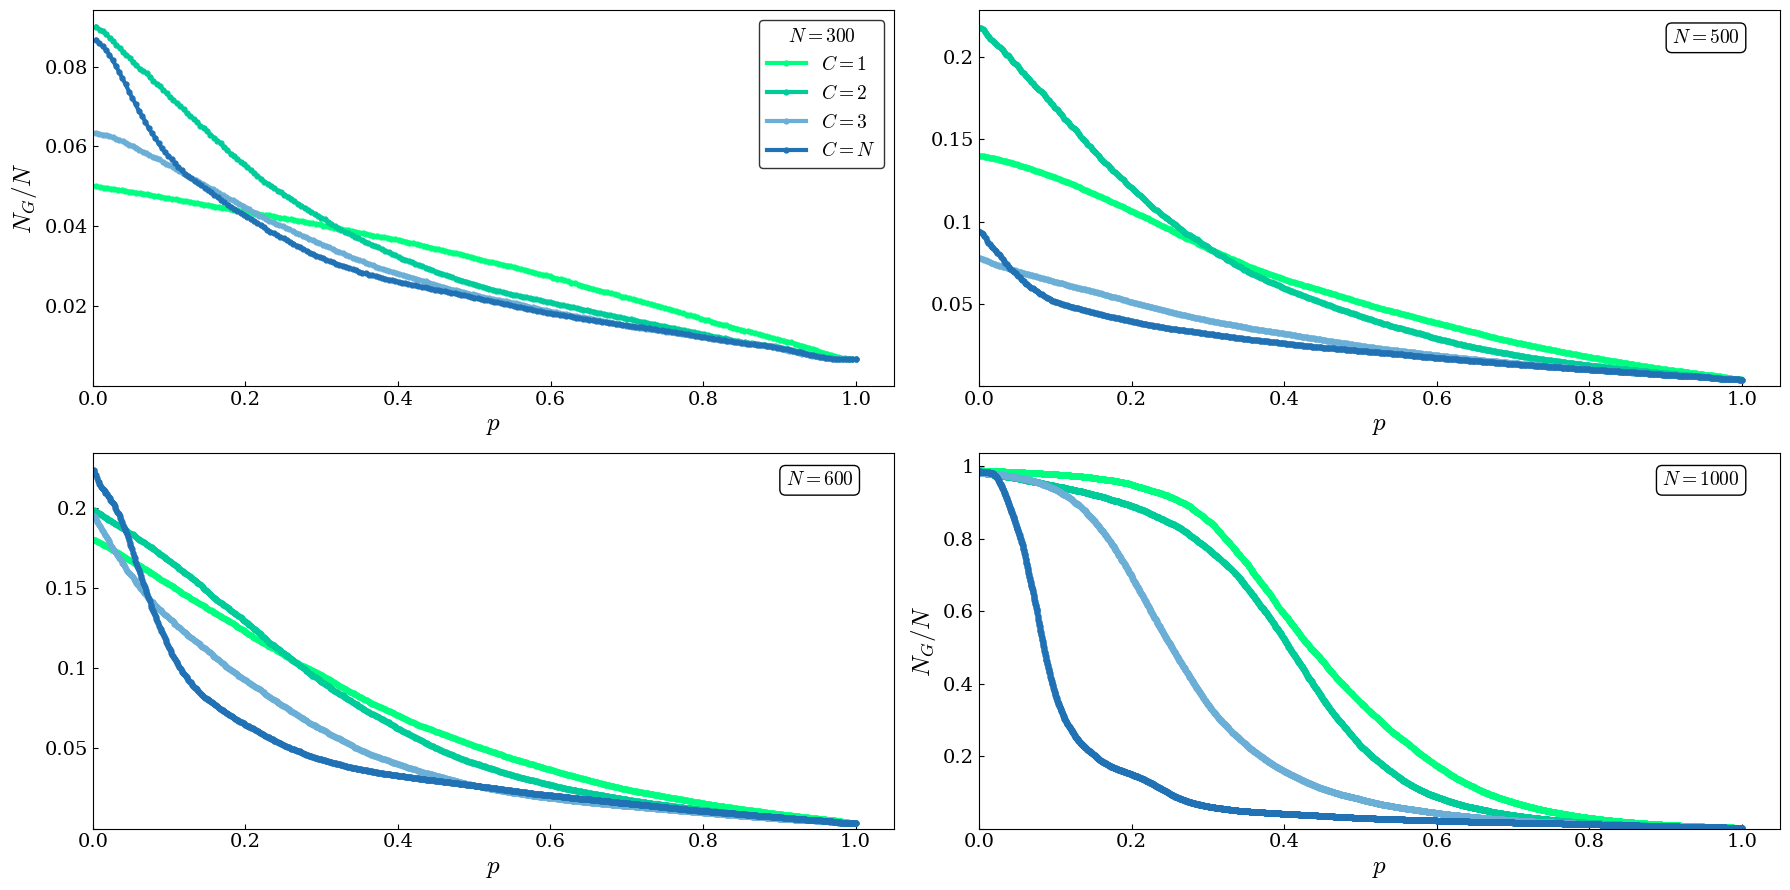

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def set_fallback_cm_fonts():
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "mathtext.fontset": "cm",
        "mathtext.rm": "serif",
        "mathtext.it": "serif:italic",
        "mathtext.bf": "serif:bold",
    })

def load_csv_attack(N, C, mode="random"):
    fname = f"./data_random_medias/{mode}_{N}_{C}.csv"
    if not os.path.exists(fname):
        print(f"[AVISO] Arquivo não encontrado: {fname}")
        return pd.DataFrame()
    df = pd.read_csv(fname, sep=',', header=0)
    return df.drop(columns=["node1", "node2"], errors="ignore")

def plot_m1_subplot(ax, N, show_legend=False):
    set_fallback_cm_fonts()

    # Cores dos epsilons 1.0, 0.75, 0.5, 0.25
    cmap = plt.cm.get_cmap('winter')
    styles = {
        'C=1': {'color': cmap(1.0), 'marker': 'o'},   # ε = 1.0
        'C=2': {'color': cmap(0.8), 'marker': 'o'},   # ε = 0.75
        'C=3': {'color': '#6BAED6', 'marker': 'o'},   # ε = 0.5
        'C=N': {'color': '#2171B5', 'marker': 'o'},   # ε = 0.25
    }

    # Carregamento
    C1_df = load_csv_attack(N, 1)
    C2_df = load_csv_attack(N, 2)
    C3_df = load_csv_attack(N, 3)
    CN_df = load_csv_attack(N, N)

    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--',  linewidth=0.5, alpha=0.7)

    # Plota m1 para cada C
    ax.plot(C1_df["p"], C1_df["m1"], label=r"$C=1$", **styles['C=1'], linewidth=3, markersize=3.5)
    ax.plot(C2_df["p"], C2_df["m1"], label=r"$C=2$", **styles['C=2'], linewidth=3, markersize=3.5)
    ax.plot(C3_df["p"], C3_df["m1"], label=r"$C=3$", **styles['C=3'], linewidth=3, markersize=3.5)
    ax.plot(CN_df["p"], CN_df["m1"], label=r"$C=N$", **styles['C=N'], linewidth=3, markersize=3.5)

    # Eixos
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$p$", fontsize=18)
    ax.set_ylabel(r"$N_{G}/N$" if N in (300, 1000) else "", fontsize=18)
    ax.tick_params(labelsize=14, direction='in')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: '' if val == 0 else f'{val:g}'))
    ax.grid(False)

    if show_legend:
        ax.legend(
            fontsize=14,
            title=rf"$N={N}$",
            title_fontsize=14,
            frameon=True,
            fancybox=True,
            edgecolor='black',
            loc='upper right'
        )
    else:
        ax.text(
            0.95, 0.95, rf"$N={N}$",
            transform=ax.transAxes,
            fontsize=14,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black')
        )

def plot_m1_multi_layout():
    Ns = [300, 500, 600, 1000]
    fig, axs = plt.subplots(2, 2, figsize=(18, 9))

    for ax, N in zip(axs.flat, Ns):
        plot_m1_subplot(ax, N, show_legend=(N == 300))

    fig.tight_layout()
    fig.savefig("attack_random_spp.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

if __name__ == "__main__":
    plot_m1_multi_layout()
